In [2]:
import pandas as pd

df = pd.read_csv('Fake_real_Data.csv')

In [3]:
df.shape

(9900, 2)

In [4]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [5]:
df.label.value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

In [6]:
df['label_num'] =df['label'].map({'Fake':0, 'Real':1})

df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.Text,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(7920,)
(1980,)


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

clf = Pipeline([
    ('vec_trigram', CountVectorizer(ngram_range=(1,3))),
    ('KNN', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.49      0.65      1000
           1       0.65      0.98      0.78       980

    accuracy                           0.73      1980
   macro avg       0.81      0.74      0.72      1980
weighted avg       0.81      0.73      0.72      1980



In [10]:
clf = Pipeline([
    ('vec_trigram', CountVectorizer(ngram_range=(1,3))),
    ('KNN', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.55      0.71      1000
           1       0.69      1.00      0.81       980

    accuracy                           0.77      1980
   macro avg       0.84      0.77      0.76      1980
weighted avg       0.84      0.77      0.76      1980



In [11]:
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline([
    ('vec_trigram', CountVectorizer(ngram_range=(3,3))),
    ('rand_forest', RandomForestClassifier())
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1000
           1       0.99      1.00      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



In [12]:
from sklearn.naive_bayes import MultinomialNB

clf = Pipeline([
    ('vec_trigram', CountVectorizer(ngram_range=(1,2))),
    ('multi_nb', MultinomialNB(alpha = 0.75))
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.98      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



In [13]:
import spacy

nlp = spacy.load("en_core_web_sm")

def pre_process(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens)

In [14]:
df['pre_processed_text'] = df['Text'].apply(pre_process)

In [15]:
df.head()

,Text,label,label_num,pre_processed_text
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,Trump surrogate BRUTALLY Stabs Pathetic VIDE...
1,U.S. conservative leader optimistic of common ...,Real,1,U.S. conservative leader optimistic common gro...
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,trump propose U.S. tax overhaul stir concern d...
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,Court Forces Ohio allow Millions illegally p...
4,Democrats say Trump agrees to work on immigrat...,Real,1,Democrats Trump agree work immigration bill wa...


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df.pre_processed_text,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)

In [17]:
clf = Pipeline([
    ('vec_n_gram', CountVectorizer(ngram_range=(3,3))),
    ('rand_forest', RandomForestClassifier())
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1000
           1       0.99      0.93      0.96       980

    accuracy                           0.96      1980
   macro avg       0.96      0.96      0.96      1980
weighted avg       0.96      0.96      0.96      1980



In [18]:
clf = Pipeline([
    ('vec_n_gram', CountVectorizer(ngram_range=(1,3))),
    ('rand_forest', RandomForestClassifier())
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1000
           1       1.00      0.99      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



Text(95.72222222222221, 0.5, 'True')

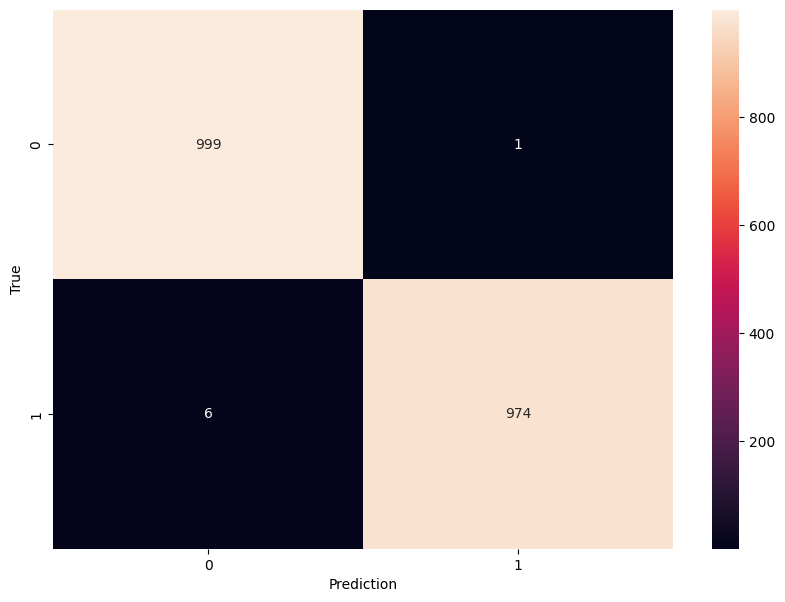

In [19]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sn

cm  =confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True,fmt='d')
plt.xlabel("Prediction")
plt.ylabel("True")